In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

             Date/Time  Temp (C)  Dew Point Temp (C)  Rel Hum (%)  \
0  2012-01-01 00:00:00      -1.8                -3.9           86   
1  2012-01-01 01:00:00      -1.8                -3.7           87   
2  2012-01-01 02:00:00      -1.8                -3.4           89   
3  2012-01-01 03:00:00      -1.5                -3.2           88   
4  2012-01-01 04:00:00      -1.5                -3.3           88   

   Wind Spd (km/h)  Visibility (km)  Stn Press (kPa)               Weather  
0                4              8.0           101.24                   Fog  
1                4              8.0           101.24                   Fog  
2                7              4.0           101.26  Freezing Drizzle,Fog  
3                6              4.0           101.27  Freezing Drizzle,Fog  
4                7              4.8           101.23                   Fog  
                Date/Time  Temp (C)  Dew Point Temp (C)  Rel Hum (%)  \
8779  2012-12-31 19:00:00       0.1                

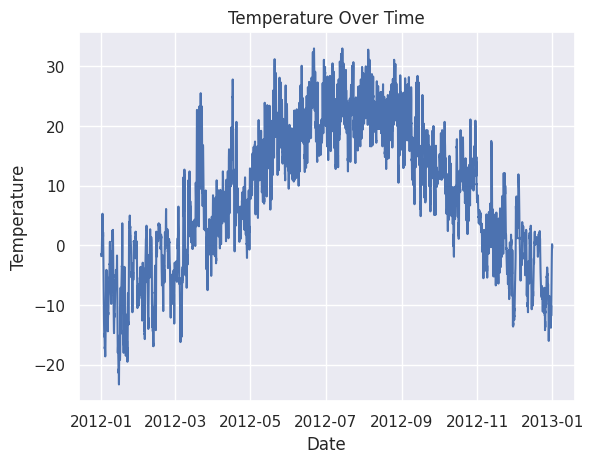

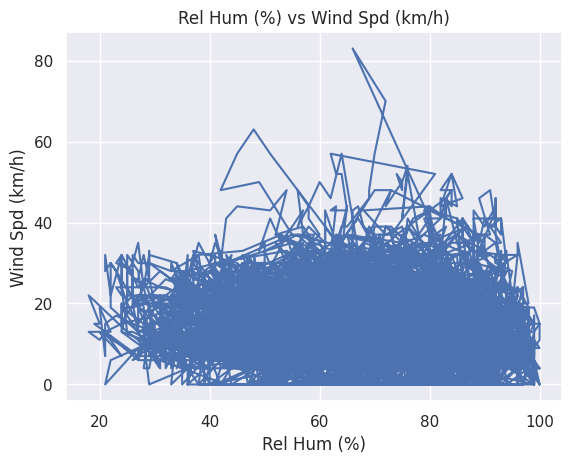

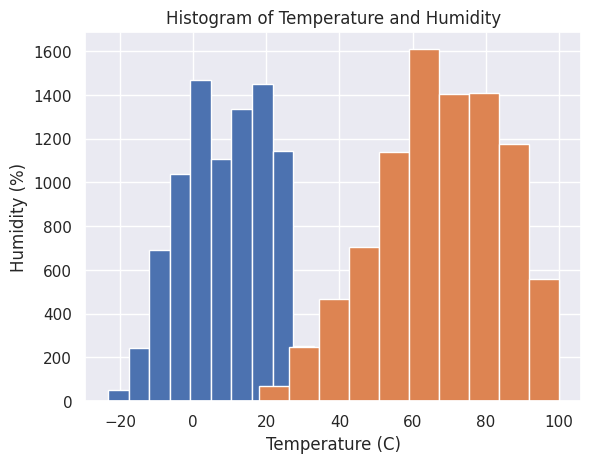

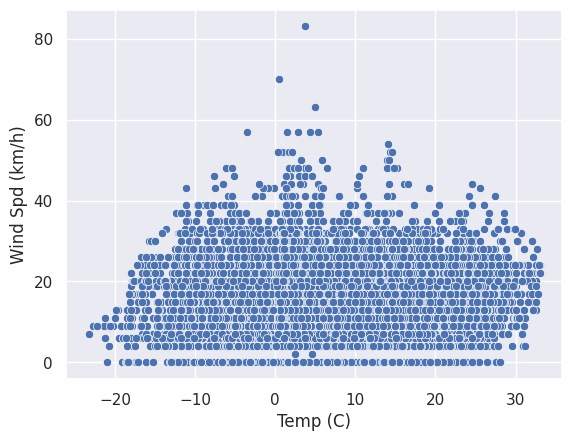

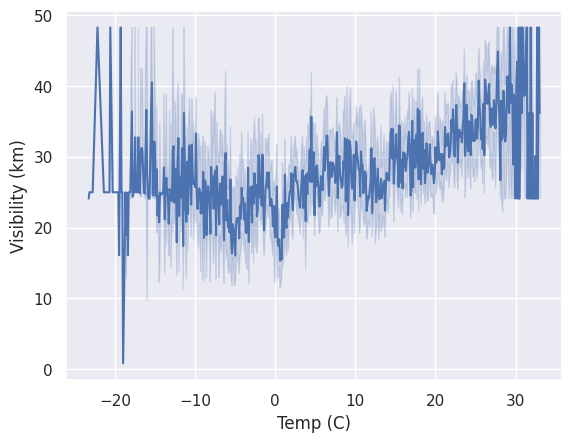

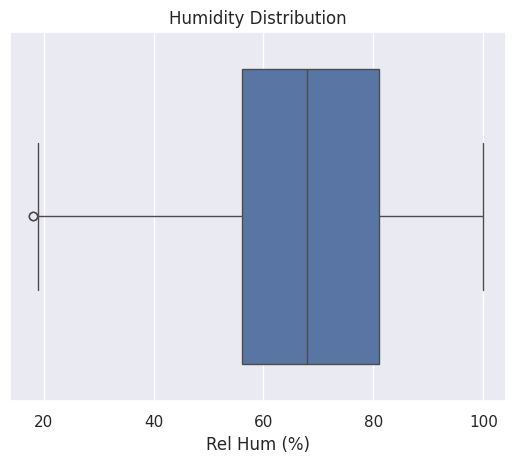

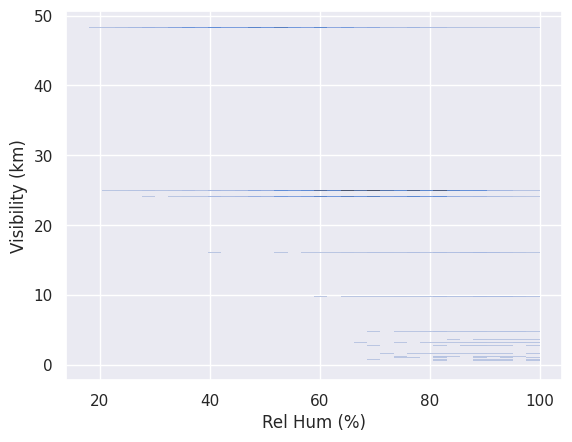

Standard Deviation: 11.687217456881875
Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                    

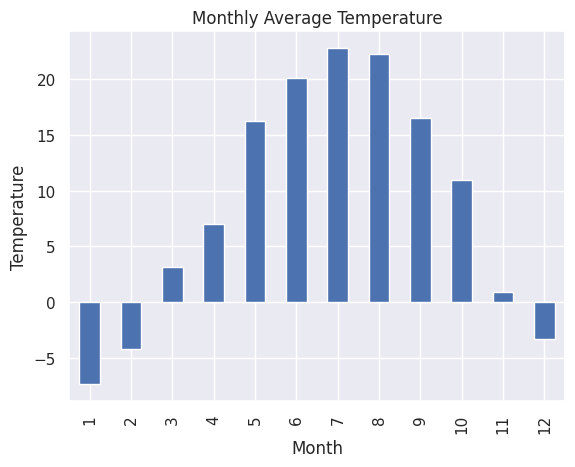

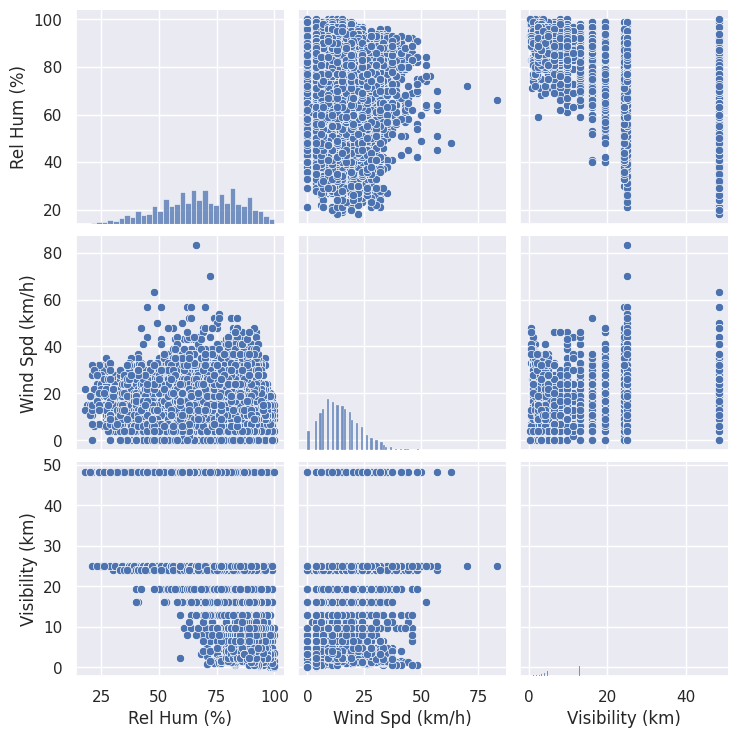

In [ ]:
df = pd.read_csv("/content/weather_data.csv")
# display basic information
print(df.head())
print(df.tail())

# for null value
print(df.isnull().sum())

# handling missing values
df = df.fillna(0)

# dispaly shape of data
print(df.shape)

#  to check column name present
print(df.columns)

# display describe of data
print(df.describe())

# convert date/time column into Date
df["Date"] = pd.to_datetime(df["Date/Time"])

# Calculate Average Temperature
print("Average Temperature:", df['Temp (C)'].mean())

# Calculate Tatol Wind speed
print("Total Wind speed:", df['Wind Spd (km/h)'].sum())

# Calculate  Maximum Humidity
print("Max Humidity:", df['Rel Hum (%)'].max())

# calculate maximum and minimum temperature
print("Max Temperature:", df['Temp (C)'].max())
print("Min Temperature:", df['Temp (C)'].min())

# displaying extreme values
print("Hottest Day:\n", df.loc[df['Temp (C)'].idxmax()])
print("Coldest Day:\n", df.loc[df['Temp (C)'].idxmin()])

#  display the line graph of date and temperature
plt.plot(df['Date'], df['Temp (C)'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Temperature Over Time')
plt.show()

# display the line graph of rel humidity and Wind speed
plt.plot(df['Rel Hum (%)'], df['Wind Spd (km/h)'])
plt.xlabel('Rel Hum (%)')
plt.ylabel('Wind Spd (km/h)')
plt.title('Rel Hum (%) vs Wind Spd (km/h)')
plt.show()

# display Histogram graph of Temperature and Humidity
plt.hist(df['Temp (C)'])
plt.hist(df['Rel Hum (%)'])
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity (%)')
plt.title('Histogram of Temperature and Humidity')
plt.show()

# display the Scatter Plot of temperature and wind speed
sns.scatterplot(x ='Temp (C)',y = 'Wind Spd (km/h)',data = df)
plt.show()

# display the line plot of Temperature and Visibility
sns.lineplot(x='Temp (C)', y='Visibility (km)', data=df)
plt.show()

# display the box graph of Humidity
sns.boxplot(x ='Rel Hum (%)',data = df)
plt.title("Humidity Distribution")
plt.show()

# display hist graph of Humidity and Visibility
sns.histplot(x ="Rel Hum (%)",y="Visibility (km)",data = df)
plt.show()

# Calculate standard deviation of temperature
temp_array = np.array(df['Temp (C)'])
print("Standard Deviation:", np.std(temp_array))

# Weather condition analysis
print(df['Weather'].value_counts())

# display grid to graph
sns.set_theme(style="darkgrid")

# display Monthly Graph
df['Month'] = df['Date'].dt.month
df.groupby('Month')['Temp (C)'].mean().plot(kind='bar')
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

# dispaly pair plot graph of humidity , Wind speed and Visibility
sns.pairplot(df[['Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)']])
plt.show()
